In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  
import re
from math import ceil
from matplotlib.patches import Rectangle

In [2]:
workspace_root = Path('/Users/christian/Documents/Study/bachelor_project')
sample_run_dir = workspace_root / 'geometry_optimization' / 'PSI_instrument' / 'sample_run_2e8n'
asymmetry_run_dir = workspace_root / 'geometry_optimization' / 'PSI_instrument' / 'asymmetry_test'
asymmetry_5cm_dir = workspace_root / 'geometry_optimization' / 'PSI_instrument' / 'asymmetry_5cm'

# Beamstop settings for the direct beam in the sample monitors.
# Spherical monitor axes are longitude [deg] and latitude [deg].
beamstop_enabled = True
beamstop_center_spherical = (0.0, 0.0)
beamstop_spherical_width_deg = 7.0
beamstop_spherical_height_deg = 10.0
beamstop_show_outline = True

# Spherical monitor cosine correction.
# Corrects longitude-latitude bins by their projected solid angle factor cos(latitude).
spherical_cosine_correction = True
spherical_cosine_floor = 1e-6
spherical_pole_cut_deg = 0.0

# Positive values roll spherical monitor data upward in latitude bins before analysis.
spherical_monitor_latitude_bin_shift = 0
spherical_shift_diagnostic_shifts = [-1, 0, 1]
spherical_shift_significant_reduction_fraction = 0.5

# Positive values roll cylindrical monitor angular bins to the right before analysis.
cylinder_monitor_angular_bin_shift = 1
cylinder_shift_diagnostic_shifts = [-2, -1, 0, 1, 2]
cylinder_shift_significant_reduction_fraction = 0.5

def _parse_float_tuple(text, n):
    values = text.split(':', 1)[1].split()
    return tuple(float(value) for value in values[:n])


def _parse_monitor_header(dat_path):
    record = {
        'path': dat_path,
    }

    with dat_path.open('r') as f:
        for line in f:
            if not line.startswith('#'):
                break

            text = line[1:].strip()

            if text.startswith('component:'):
                record['component'] = text.split(':', 1)[1].strip()
            elif text.startswith('xylimits:'):
                record['xylimits'] = _parse_float_tuple(text, 4)
            elif text.startswith('type: array_2d'):
                match = re.search(r'array_2d\((\d+),\s*(\d+)\)', text)
                if match:
                    x_bins = int(match.group(1))
                    y_bins = int(match.group(2))
                    record['shape'] = (y_bins, x_bins)
            elif text.startswith('statistics:'):
                match_x = re.search(r'X0=([^;]+)', text)
                match_y = re.search(r'Y0=([^;]+)', text)
                if match_x:
                    record['x0'] = float(match_x.group(1))
                if match_y:
                    record['y0'] = float(match_y.group(1))

    return record


def load_monitor_headers(run_dir):
    monitor_names = [
        'asymmetry_4PI_test.dat',
        'sample_cylinder_monitor.dat',
        'sample_spherical_monitor.dat',
    ]

    records = []
    for monitor_name in monitor_names:
        dat_path = run_dir / monitor_name
        if dat_path.exists():
            records.append(_parse_monitor_header(dat_path))

    return records


def beamstop_parameters(record):
    name = record['path'].stem
    component = record.get('component', '')
    if 'sample_spherical_monitor' in {name, component}:
        return {
            'center': beamstop_center_spherical,
            'width': beamstop_spherical_width_deg,
            'height': beamstop_spherical_height_deg,
            'x_unit': 'deg',
            'y_unit': 'deg',
        }
    return None


def coordinate_centers(record):
    extent = record.get('xylimits')
    if extent is None:
        return None, None

    x_min, x_max, y_min, y_max = extent
    if 'shape' in record:
        y_bins, x_bins = record['shape']
    else:
        y_bins, x_bins = record['I'].shape
    x_edges = np.linspace(x_min, x_max, x_bins + 1)
    y_edges = np.linspace(y_min, y_max, y_bins + 1)
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    return x_centers, y_centers

# Quick print of monitor center coordinates and bin-center ranges.
records = globals().get('records') or load_monitor_headers(sample_run_dir)
if not records:
    print(f'No monitor records found in {sample_run_dir}')
else:
    print(f'Monitor center check from {sample_run_dir}')
    for record in records:
        x_centers, y_centers = coordinate_centers(record)
        if x_centers is not None and y_centers is not None:
            x_mid = x_centers[len(x_centers) // 2]
            y_mid = y_centers[len(y_centers) // 2]
            print(f"Record: {record['path'].name}")
            if 'x0' in record and 'y0' in record:
                print(f"  intensity center X0/Y0: {record['x0']:.6g}, {record['y0']:.6g}")
            print(f"  x bin centers: first={x_centers[0]:.6g}, mid={x_mid:.6g}, last={x_centers[-1]:.6g}, n={len(x_centers)}")
            print(f"  y bin centers: first={y_centers[0]:.6g}, mid={y_mid:.6g}, last={y_centers[-1]:.6g}, n={len(y_centers)}")


Monitor center check from /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/sample_run_2e8n
Record: sample_cylinder_monitor.dat
  intensity center X0/Y0: -1.82819, -4.5404e-05
  x bin centers: first=-179, mid=1, last=179, n=180
  y bin centers: first=-4.94444, mid=0.0555556, last=4.94444, n=90
Record: sample_spherical_monitor.dat
  intensity center X0/Y0: 0.130474, 0.996418
  x bin centers: first=-179, mid=1, last=179, n=180
  y bin centers: first=-89, mid=1, last=89, n=90


Record: asymmetry_4PI_test.dat
  spherical latitude-bin shift diagnostic:
    shift bins    full |asym|    zoom |asym|
            -1      0.0494306      0.0494304
            +0      0.0475249      0.0475247
            +1       0.143004       0.142999
    configured shift +0: zoom |asym| reduction = 0.0%
    significant reduction: False
  full corrected north integrated intensity: 2.40926e+07
  full corrected south integrated intensity: 2.19065e+07
  full (north - south) / total: 0.0475249
  zoom corrected north integrated intensity: 2.40926e+07
  zoom corrected south integrated intensity: 2.19065e+07
  zoom (north - south) / total: 0.0475247


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_22167/113033711.py:26: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=900`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  record['I'] = np.loadtxt(


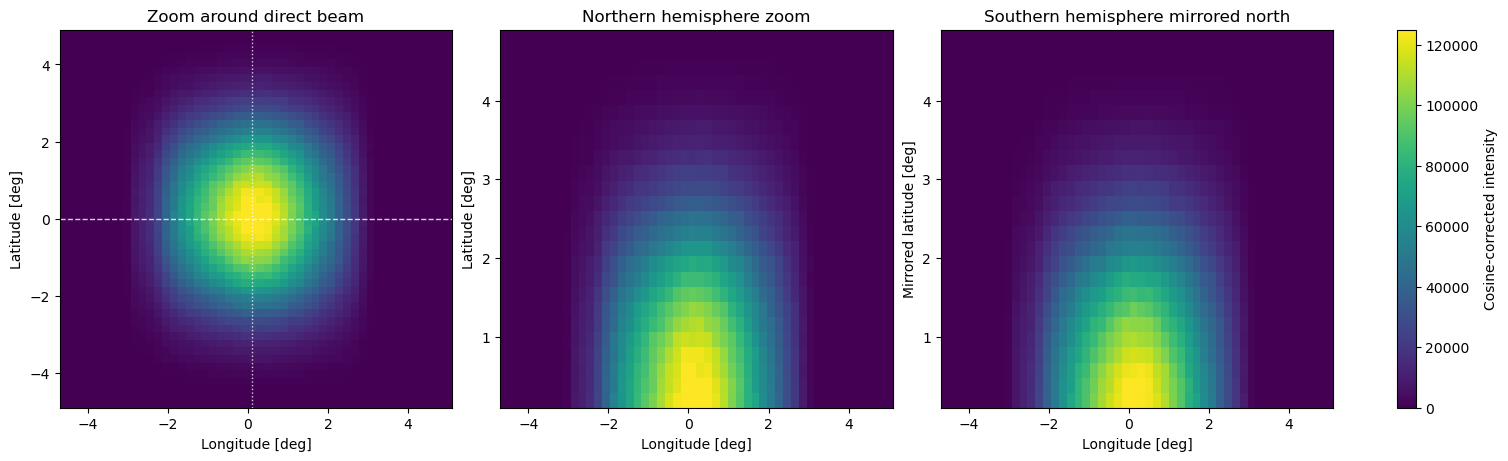

In [3]:
def is_spherical_monitor_record(record):
    name = record['path'].stem
    component = record.get('component', '')
    spherical_names = {
        'asymmetry_4PI_test',
        'sample_spherical_monitor',
        'sample_spherical_monitor_scattered',
    }
    return name in spherical_names or component in spherical_names


def shift_spherical_latitude_bins(record, shift, *, reason='manual latitude bin shift'):
    if shift == 0 or not is_spherical_monitor_record(record):
        return record

    shifted = dict(record)
    shifted['I'] = np.roll(record['I'], shift, axis=0).copy()
    shifted['latitude_bin_shift'] = shift
    shifted['comparison_note'] = f'{reason}: {shift:+d} bins'
    return shifted


def load_monitor_intensity(dat_path, *, apply_spherical_shift=True):
    record = _parse_monitor_header(dat_path)
    y_bins, x_bins = record['shape']
    record['I'] = np.loadtxt(
        dat_path,
        comments='#',
        max_rows=y_bins,
    )
    if apply_spherical_shift:
        record = shift_spherical_latitude_bins(
            record,
            spherical_monitor_latitude_bin_shift,
            reason='spherical monitor latitude convention correction',
        )
    return record


def plot_asymmetry_4pi_zoom_and_mirror(run_dir):
    dat_path = run_dir / 'asymmetry_4PI_test.dat'
    if not dat_path.exists():
        raise FileNotFoundError(dat_path)

    raw_record = load_monitor_intensity(dat_path, apply_spherical_shift=False)
    record = shift_spherical_latitude_bins(
        raw_record,
        spherical_monitor_latitude_bin_shift,
        reason='spherical monitor latitude convention correction',
    )
    H_raw = record['I']
    x_centers, y_centers = coordinate_centers(record)

    latitude_cosine = np.cos(
        np.deg2rad(y_centers)
    )[:, np.newaxis]
    safe_latitude_cosine = np.where(
        np.abs(latitude_cosine) > spherical_cosine_floor,
        latitude_cosine,
        np.nan,
    )
    H = H_raw / safe_latitude_cosine

    zoom_lon_halfwidth_deg = 5.0
    zoom_lat_halfwidth_deg = 5.0
    zoom_center_lon = record.get('x0', 0.0)

    lon_mask = np.abs(x_centers - zoom_center_lon) <= zoom_lon_halfwidth_deg
    lat_zoom_mask = np.abs(y_centers) <= zoom_lat_halfwidth_deg

    def north_south_fractional_difference(H_candidate_raw):
        H_candidate = H_candidate_raw / safe_latitude_cosine
        north = np.nansum(H_candidate[y_centers > 0.0, :])
        south = np.nansum(H_candidate[y_centers < 0.0, :])
        total = north + south
        full_frac = (north - south) / total if total > 0.0 else np.nan

        north_zoom_mask = (y_centers > 0.0) & (y_centers <= zoom_lat_halfwidth_deg)
        south_zoom_mask = (y_centers < 0.0) & (-y_centers <= zoom_lat_halfwidth_deg)
        north_zoom = np.nansum(H_candidate[np.ix_(north_zoom_mask, lon_mask)])
        south_zoom = np.nansum(H_candidate[np.ix_(south_zoom_mask, lon_mask)])
        zoom_total = north_zoom + south_zoom
        zoom_frac = (north_zoom - south_zoom) / zoom_total if zoom_total > 0.0 else np.nan
        return full_frac, zoom_frac

    shift_metrics = []
    for shift in spherical_shift_diagnostic_shifts:
        candidate = np.roll(raw_record['I'], shift, axis=0)
        full_frac, zoom_frac = north_south_fractional_difference(candidate)
        shift_metrics.append((shift, full_frac, zoom_frac))
    north_mask = (y_centers > 0.0) & (y_centers <= zoom_lat_halfwidth_deg)
    south_mask = (y_centers < 0.0) & (-y_centers <= zoom_lat_halfwidth_deg)

    H_zoom = H[np.ix_(lat_zoom_mask, lon_mask)]
    H_north = H[np.ix_(north_mask, lon_mask)]
    H_south_mirrored = H[np.ix_(south_mask, lon_mask)][::-1, :]

    lon_zoom = x_centers[lon_mask]
    lat_zoom = y_centers[lat_zoom_mask]
    lat_north = y_centers[north_mask]
    lat_south_mirrored = -y_centers[south_mask][::-1]

    north_integrated = np.nansum(H[y_centers > 0.0, :])
    south_integrated = np.nansum(H[y_centers < 0.0, :])
    total_integrated = north_integrated + south_integrated
    fractional_difference = (
        (north_integrated - south_integrated) / total_integrated
        if total_integrated > 0.0 else np.nan
    )
    north_zoom_integrated = np.nansum(H_north)
    south_zoom_integrated = np.nansum(H_south_mirrored)
    total_zoom_integrated = north_zoom_integrated + south_zoom_integrated
    zoom_fractional_difference = (
        (north_zoom_integrated - south_zoom_integrated) / total_zoom_integrated
        if total_zoom_integrated > 0.0 else np.nan
    )

    print(f'Record: {dat_path.name}')
    print('  spherical latitude-bin shift diagnostic:')
    print('    shift bins    full |asym|    zoom |asym|')
    for shift, full_frac, zoom_frac in shift_metrics:
        print(f'    {shift:+10d}    {abs(full_frac):11.6g}    {abs(zoom_frac):11.6g}')
    baseline = next((item for item in shift_metrics if item[0] == 0), None)
    configured = next((item for item in shift_metrics if item[0] == spherical_monitor_latitude_bin_shift), None)
    if baseline is not None and configured is not None:
        baseline_zoom = abs(baseline[2])
        configured_zoom = abs(configured[2])
        reduction = 1.0 - configured_zoom / baseline_zoom if baseline_zoom > 0.0 else np.nan
        significant = reduction >= spherical_shift_significant_reduction_fraction
        print(f'    configured shift {spherical_monitor_latitude_bin_shift:+d}: zoom |asym| reduction = {reduction:.1%}')
        print(f'    significant reduction: {significant}')
    print(f'  full corrected north integrated intensity: {north_integrated:.6g}')
    print(f'  full corrected south integrated intensity: {south_integrated:.6g}')
    print(f'  full (north - south) / total: {fractional_difference:.6g}')
    print(f'  zoom corrected north integrated intensity: {north_zoom_integrated:.6g}')
    print(f'  zoom corrected south integrated intensity: {south_zoom_integrated:.6g}')
    print(f'  zoom (north - south) / total: {zoom_fractional_difference:.6g}')

    vmin = np.nanpercentile(H_zoom, 1.0)
    vmax = np.nanpercentile(H_zoom, 99.5)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.5),
        constrained_layout=True,
    )

    im0 = axes[0].imshow(
        H_zoom,
        origin='lower',
        aspect='auto',
        extent=[lon_zoom[0], lon_zoom[-1], lat_zoom[0], lat_zoom[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[0].axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
    axes[0].axvline(record.get('x0', 0.0), color='white', linestyle=':', linewidth=1.0, alpha=0.8)
    axes[0].set_title('Zoom around direct beam')
    axes[0].set_xlabel('Longitude [deg]')
    axes[0].set_ylabel('Latitude [deg]')

    axes[1].imshow(
        H_north,
        origin='lower',
        aspect='auto',
        extent=[lon_zoom[0], lon_zoom[-1], lat_north[0], lat_north[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[1].set_title('Northern hemisphere zoom')
    axes[1].set_xlabel('Longitude [deg]')
    axes[1].set_ylabel('Latitude [deg]')

    axes[2].imshow(
        H_south_mirrored,
        origin='lower',
        aspect='auto',
        extent=[lon_zoom[0], lon_zoom[-1], lat_south_mirrored[0], lat_south_mirrored[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[2].set_title('Southern hemisphere mirrored north')
    axes[2].set_xlabel('Longitude [deg]')
    axes[2].set_ylabel('Mirrored latitude [deg]')

    fig.colorbar(
        im0,
        ax=axes,
        label='Cosine-corrected intensity',
    )

    plt.show()


plot_asymmetry_4pi_zoom_and_mirror(
    workspace_root / 'geometry_optimization' / 'PSI_instrument' / 'asymmetry_h5cm'
)


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_22167/113033711.py:26: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=90`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  record['I'] = np.loadtxt(


Record center from McStas statistics: X0=0.235523, Y0=0.999555
Nearest longitude bin to 0 deg: -1
Nearest latitude bin to 0 deg: -1
spherical direct-beam latitude-bin shift diagnostic:
  shift bins    raw full |asym|    raw outside |asym|    corrected full |asym|    corrected outside |asym|
          -1           0.014729             0.0147758                0.0542187                   0.0542908
          +0          0.0148742             0.0149216                0.0577833                   0.0578593
          +1           0.043678             0.0438056                 0.120841                    0.120998
Record: sample_spherical_monitor_scattered.dat (raw)
  pole cut: excluded |latitude| > 90 deg
  north integrated intensity: 948372
  south integrated intensity: 920573
  total integrated intensity: 1.86895e+06
  (north - south) / total: 0.0148742
  direct-beam window center used: lon=0.235523 deg, lat=0.999555 deg
  direct-beam window halfwidths: lon=3.5 deg, lat=5 deg
  north direct-

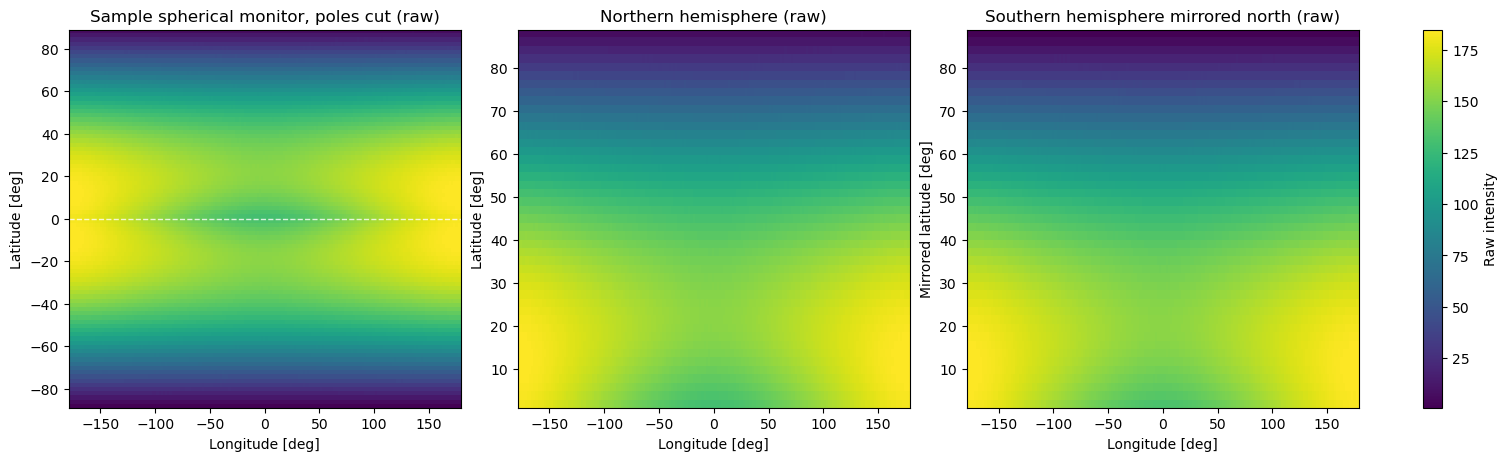

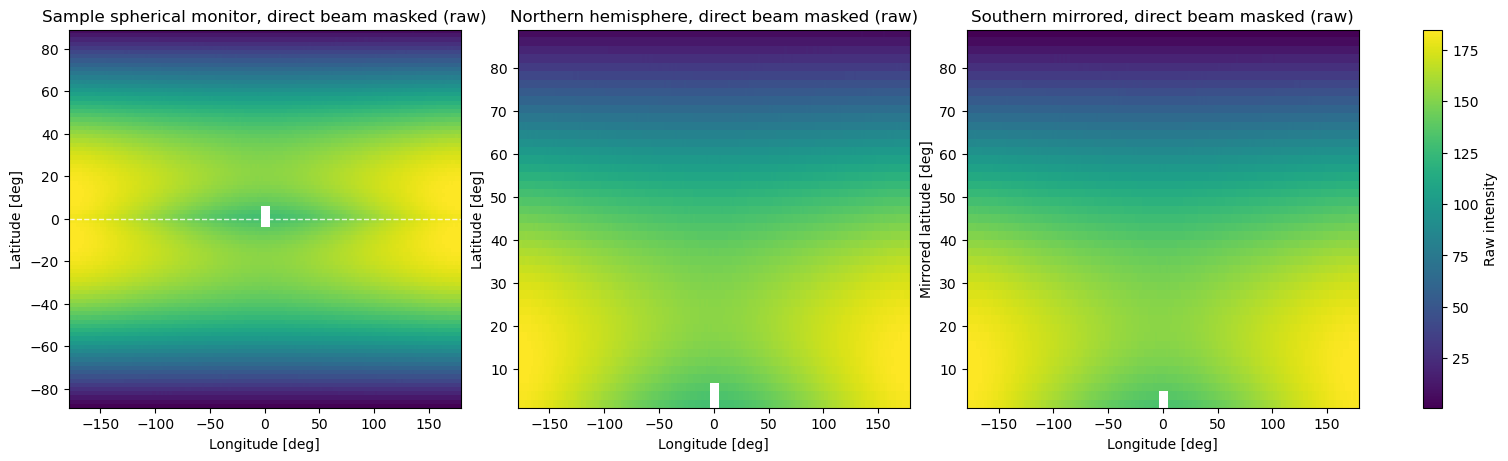

Record: sample_spherical_monitor_scattered.dat (cosine corrected)
  pole cut: excluded |latitude| > 90 deg
  north integrated intensity: 1.58702e+06
  south integrated intensity: 1.41363e+06
  total integrated intensity: 3.00064e+06
  (north - south) / total: 0.0577833
  direct-beam window center used: lon=0.235523 deg, lat=0.999555 deg
  direct-beam window halfwidths: lon=3.5 deg, lat=5 deg
  north direct-beam-window intensity: 1600.73 (0.10% of north)
  south mirrored direct-beam-window intensity: 1641.08 (0.12% of south)
  north intensity outside direct-beam window: 1.58542e+06
  south intensity outside direct-beam window: 1.41199e+06
  outside-beam (north - south) / total: 0.0578593
  north/south ratio outside direct-beam window: 1.12283


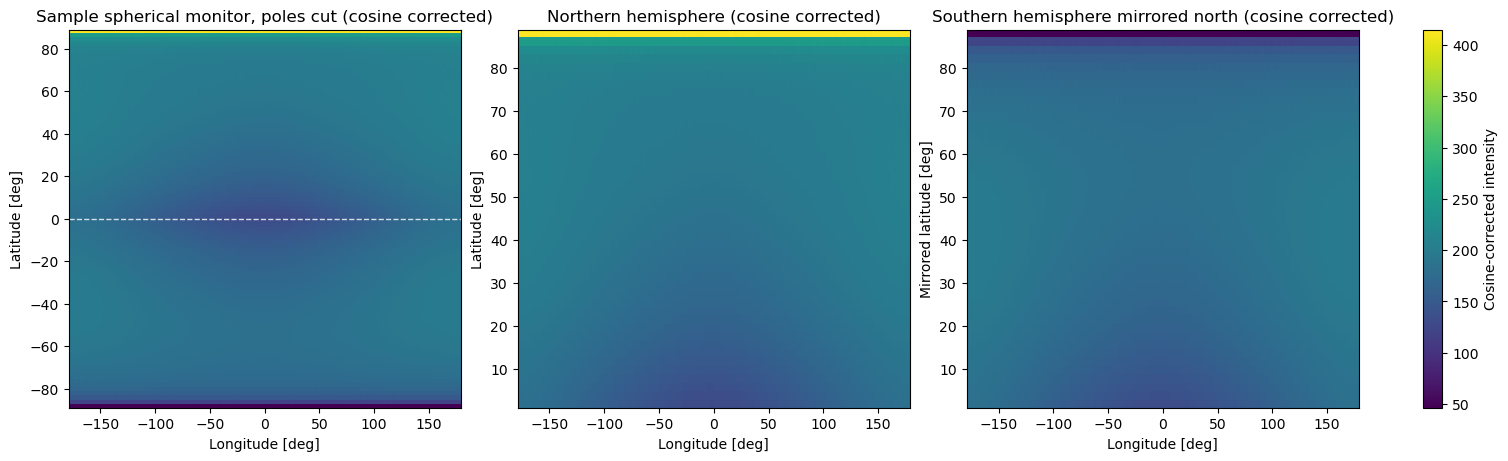

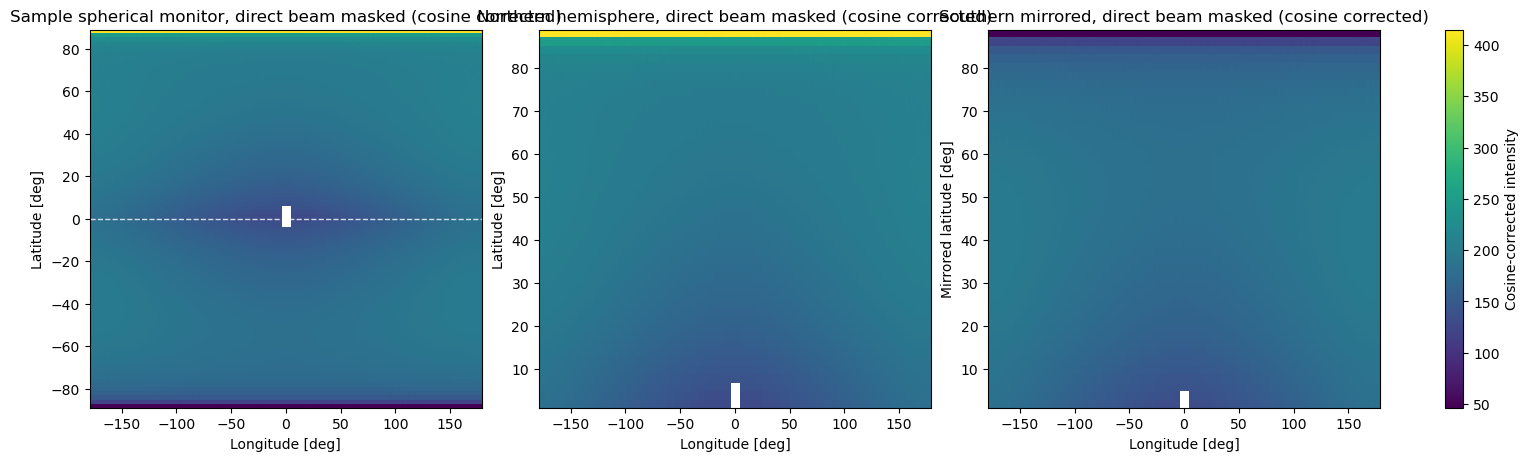

In [4]:
def plot_sample_spherical_north_south_check(run_dir):
    dat_path = run_dir / 'sample_spherical_monitor_scattered.dat'
    if not dat_path.exists():
        raise FileNotFoundError(dat_path)

    raw_record = load_monitor_intensity(dat_path, apply_spherical_shift=False)
    record = shift_spherical_latitude_bins(
        raw_record,
        spherical_monitor_latitude_bin_shift,
        reason='spherical monitor latitude convention correction',
    )
    H_raw = record['I']
    x_centers, y_centers = coordinate_centers(record)

    print(f'Record center from McStas statistics: X0={record.get("x0", np.nan):.6g}, Y0={record.get("y0", np.nan):.6g}')
    print(f'Nearest longitude bin to 0 deg: {x_centers[np.argmin(np.abs(x_centers))]:.6g}')
    print(f'Nearest latitude bin to 0 deg: {y_centers[np.argmin(np.abs(y_centers))]:.6g}')

    latitude_cosine = np.cos(
        np.deg2rad(y_centers)
    )[:, np.newaxis]
    safe_latitude_cosine = np.where(
        np.abs(latitude_cosine) > spherical_cosine_floor,
        latitude_cosine,
        np.nan,
    )
    H_corrected = H_raw / safe_latitude_cosine

    pole_cut_deg = 0.0
    max_abs_latitude = 90.0 - pole_cut_deg
    valid_lat_mask = np.abs(y_centers) <= max_abs_latitude
    north_mask = (y_centers > 0.0) & valid_lat_mask
    south_mask = (y_centers < 0.0) & valid_lat_mask

    lat_cut = y_centers[valid_lat_mask]
    lat_north = y_centers[north_mask]
    lat_south_mirrored = -y_centers[south_mask][::-1]

    beam_lon_halfwidth_deg = beamstop_spherical_width_deg / 2.0
    beam_lat_halfheight_deg = beamstop_spherical_height_deg / 2.0
    beam_center_lon = record.get('x0', beamstop_center_spherical[0])
    beam_center_lat = record.get('y0', beamstop_center_spherical[1])
    beam_lon_mask = np.abs(x_centers - beam_center_lon) <= beam_lon_halfwidth_deg
    beam_lat_mask = np.abs(y_centers - beam_center_lat) <= beam_lat_halfheight_deg

    def spherical_direct_beam_asymmetry_metrics(H_candidate):
        H_north = H_candidate[north_mask, :]
        H_south_mirrored = H_candidate[south_mask, :][::-1, :]
        north_integrated = np.nansum(H_north)
        south_integrated = np.nansum(H_south_mirrored)
        total_integrated = north_integrated + south_integrated
        full_frac = (
            (north_integrated - south_integrated) / total_integrated
            if total_integrated > 0.0 else np.nan
        )

        north_beam_mask = north_mask & beam_lat_mask
        south_beam_mirror_mask = south_mask & (np.abs((-y_centers) - beam_center_lat) <= beam_lat_halfheight_deg)
        north_beam_integrated = np.nansum(H_candidate[np.ix_(north_beam_mask, beam_lon_mask)])
        south_beam_integrated = np.nansum(H_candidate[np.ix_(south_beam_mirror_mask, beam_lon_mask)])
        north_without_beam = north_integrated - north_beam_integrated
        south_without_beam = south_integrated - south_beam_integrated
        no_beam_total = north_without_beam + south_without_beam
        outside_frac = (
            (north_without_beam - south_without_beam) / no_beam_total
            if no_beam_total > 0.0 else np.nan
        )
        return full_frac, outside_frac

    print('spherical direct-beam latitude-bin shift diagnostic:')
    print('  shift bins    raw full |asym|    raw outside |asym|    corrected full |asym|    corrected outside |asym|')
    for shift in spherical_shift_diagnostic_shifts:
        shifted_raw = np.roll(raw_record['I'], shift, axis=0)
        shifted_corrected = shifted_raw / safe_latitude_cosine
        raw_full, raw_outside = spherical_direct_beam_asymmetry_metrics(shifted_raw)
        corrected_full, corrected_outside = spherical_direct_beam_asymmetry_metrics(shifted_corrected)
        print(
            f'  {shift:+10d}'
            f'    {abs(raw_full):15.6g}'
            f'    {abs(raw_outside):18.6g}'
            f'    {abs(corrected_full):21.6g}'
            f'    {abs(corrected_outside):24.6g}'
        )

    def plot_one(H, label, colorbar_label):
        H_cut = H[valid_lat_mask, :]
        H_north = H[north_mask, :]
        H_south_mirrored = H[south_mask, :][::-1, :]

        north_integrated = np.nansum(H_north)
        south_integrated = np.nansum(H_south_mirrored)
        total_integrated = north_integrated + south_integrated

        north_beam_mask = north_mask & beam_lat_mask
        south_beam_mirror_mask = south_mask & (np.abs((-y_centers) - beam_center_lat) <= beam_lat_halfheight_deg)
        north_beam_integrated = np.nansum(H[np.ix_(north_beam_mask, beam_lon_mask)])
        south_beam_integrated = np.nansum(H[np.ix_(south_beam_mirror_mask, beam_lon_mask)])
        north_without_beam = north_integrated - north_beam_integrated
        south_without_beam = south_integrated - south_beam_integrated
        fractional_difference = (
            (north_integrated - south_integrated) / total_integrated
            if total_integrated > 0.0 else np.nan
        )

        print(f'Record: {dat_path.name} ({label})')
        print(f'  pole cut: excluded |latitude| > {max_abs_latitude:g} deg')
        print(f'  north integrated intensity: {north_integrated:.6g}')
        print(f'  south integrated intensity: {south_integrated:.6g}')
        print(f'  total integrated intensity: {total_integrated:.6g}')
        print(f'  (north - south) / total: {fractional_difference:.6g}')
        print(f'  direct-beam window center used: lon={beam_center_lon:.6g} deg, lat={beam_center_lat:.6g} deg')
        print(f'  direct-beam window halfwidths: lon={beam_lon_halfwidth_deg:.6g} deg, lat={beam_lat_halfheight_deg:.6g} deg')
        print(f'  north direct-beam-window intensity: {north_beam_integrated:.6g} ({north_beam_integrated / north_integrated:.2%} of north)')
        print(f'  south mirrored direct-beam-window intensity: {south_beam_integrated:.6g} ({south_beam_integrated / south_integrated:.2%} of south)')
        no_beam_total = north_without_beam + south_without_beam
        no_beam_fractional_difference = (
            (north_without_beam - south_without_beam) / no_beam_total
            if no_beam_total > 0.0 else np.nan
        )
        print(f'  north intensity outside direct-beam window: {north_without_beam:.6g}')
        print(f'  south intensity outside direct-beam window: {south_without_beam:.6g}')
        print(f'  outside-beam (north - south) / total: {no_beam_fractional_difference:.6g}')
        print(f'  north/south ratio outside direct-beam window: {north_without_beam / south_without_beam:.6g}')

        H_no_beam = H.copy()
        H_no_beam[np.ix_(beam_lat_mask, beam_lon_mask)] = np.nan
        H_no_beam_cut = H_no_beam[valid_lat_mask, :]
        H_no_beam_north = H_no_beam[north_mask, :]
        H_no_beam_south_mirrored = H_no_beam[south_mask, :][::-1, :]

        vmin = np.nanpercentile(H_cut, 1.0)
        vmax = np.nanpercentile(H_cut, 99.5)

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(15, 4.5),
            constrained_layout=True,
        )

        im0 = axes[0].imshow(
            H_cut,
            origin='lower',
            aspect='auto',
            extent=[x_centers[0], x_centers[-1], lat_cut[0], lat_cut[-1]],
            interpolation='nearest',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )
        axes[0].axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
        axes[0].set_title(f'Sample spherical monitor, poles cut ({label})')
        axes[0].set_xlabel('Longitude [deg]')
        axes[0].set_ylabel('Latitude [deg]')

        axes[1].imshow(
            H_north,
            origin='lower',
            aspect='auto',
            extent=[x_centers[0], x_centers[-1], lat_north[0], lat_north[-1]],
            interpolation='nearest',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )
        axes[1].set_title(f'Northern hemisphere ({label})')
        axes[1].set_xlabel('Longitude [deg]')
        axes[1].set_ylabel('Latitude [deg]')

        axes[2].imshow(
            H_south_mirrored,
            origin='lower',
            aspect='auto',
            extent=[x_centers[0], x_centers[-1], lat_south_mirrored[0], lat_south_mirrored[-1]],
            interpolation='nearest',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )
        axes[2].set_title(f'Southern hemisphere mirrored north ({label})')
        axes[2].set_xlabel('Longitude [deg]')
        axes[2].set_ylabel('Mirrored latitude [deg]')

        fig.colorbar(
            im0,
            ax=axes,
            label=colorbar_label,
        )

        plt.show()

        masked_vmin = np.nanpercentile(H_no_beam_cut, 1.0)
        masked_vmax = np.nanpercentile(H_no_beam_cut, 99.5)
        fig, axes = plt.subplots(
            1,
            3,
            figsize=(15, 4.5),
            constrained_layout=True,
        )

        im0 = axes[0].imshow(
            H_no_beam_cut,
            origin='lower',
            aspect='auto',
            extent=[x_centers[0], x_centers[-1], lat_cut[0], lat_cut[-1]],
            interpolation='nearest',
            cmap='viridis',
            vmin=masked_vmin,
            vmax=masked_vmax,
        )
        axes[0].axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
        axes[0].set_title(f'Sample spherical monitor, direct beam masked ({label})')
        axes[0].set_xlabel('Longitude [deg]')
        axes[0].set_ylabel('Latitude [deg]')

        axes[1].imshow(
            H_no_beam_north,
            origin='lower',
            aspect='auto',
            extent=[x_centers[0], x_centers[-1], lat_north[0], lat_north[-1]],
            interpolation='nearest',
            cmap='viridis',
            vmin=masked_vmin,
            vmax=masked_vmax,
        )
        axes[1].set_title(f'Northern hemisphere, direct beam masked ({label})')
        axes[1].set_xlabel('Longitude [deg]')
        axes[1].set_ylabel('Latitude [deg]')

        axes[2].imshow(
            H_no_beam_south_mirrored,
            origin='lower',
            aspect='auto',
            extent=[x_centers[0], x_centers[-1], lat_south_mirrored[0], lat_south_mirrored[-1]],
            interpolation='nearest',
            cmap='viridis',
            vmin=masked_vmin,
            vmax=masked_vmax,
        )
        axes[2].set_title(f'Southern mirrored, direct beam masked ({label})')
        axes[2].set_xlabel('Longitude [deg]')
        axes[2].set_ylabel('Mirrored latitude [deg]')

        fig.colorbar(
            im0,
            ax=axes,
            label=colorbar_label,
        )

        plt.show()

    plot_one(
        H_raw,
        'raw',
        'Raw intensity',
    )
    plot_one(
        H_corrected,
        'cosine corrected',
        'Cosine-corrected intensity',
    )


plot_sample_spherical_north_south_check(
    workspace_root / 'geometry_optimization' / 'PSI_instrument' / 'PSI_settings_1e11'
)


  angular edge-column check:
          first column: sum=0, nonzero=0/90
    second_last column: sum=10390.6, nonzero=90/90
           last column: sum=10390.6, nonzero=90/90
  top/bottom row intensity check:
    bottom row fraction:       5.01778e-05
    row 1 fraction:            6.86753e-05
    bottom / row 1:            0.730652
    nearby row 1 / row 2:      0.941701
    top row fraction:          5.01735e-05
    row -2 fraction:           6.86907e-05
    top / row -2:              0.730426
    nearby row -2 / row -3:    0.941786
  left/right angular asymmetry check:
    all matched pairs:
      matched pairs:              90
      left sum:                   0.461476
      right sum:                  0.538524
      (left-right)/(left+right):  -0.0770474
      mean |pair frac asym|:      0.0133445
      RMS pair frac asym:         0.105797
      largest signed angular-pair contributions:
        -3.0 vs  3.0 deg: diff=-0.0390073, frac=-0.282642
        -1.0 vs  1.0 deg: diff=-0.03

/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_22167/113033711.py:26: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=90`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  record['I'] = np.loadtxt(


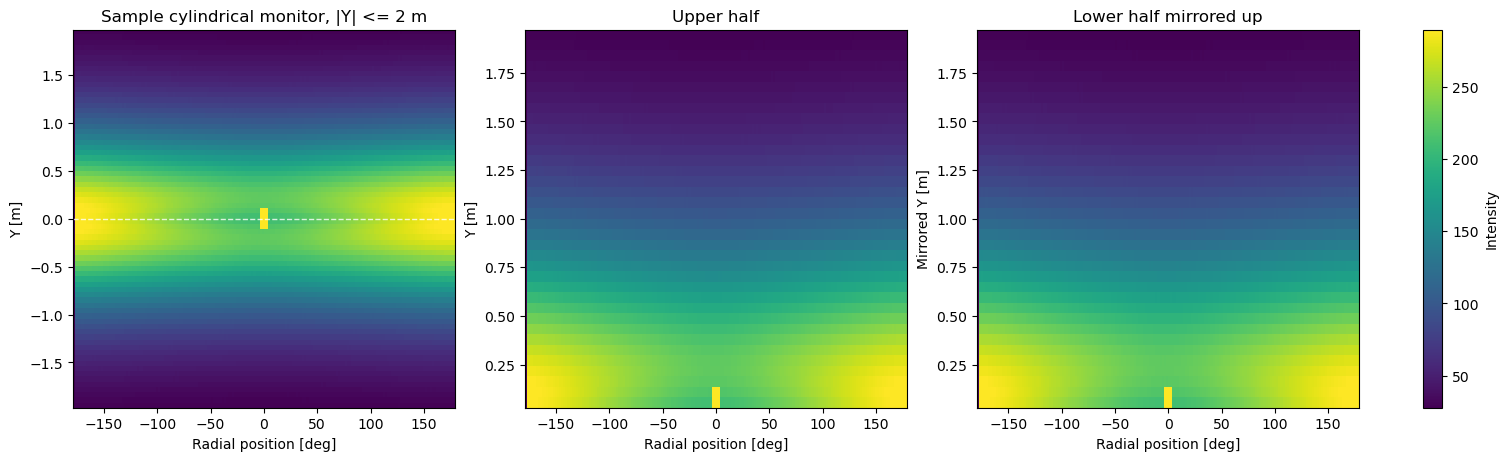

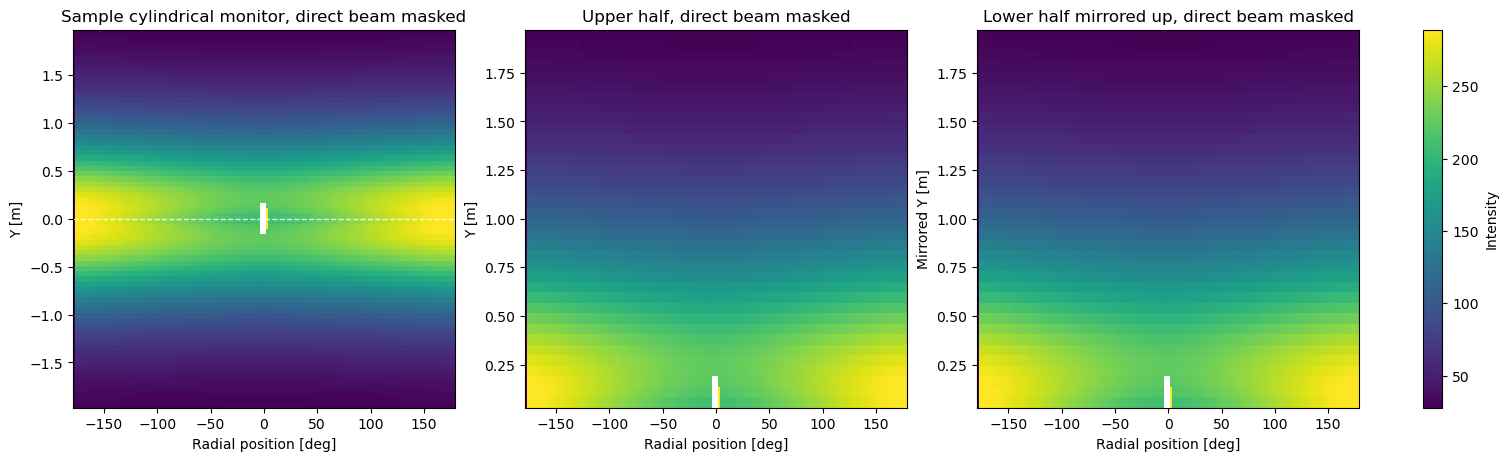

In [5]:
def shift_cylinder_angular_bins(record, shift, *, reason='manual angular bin shift'):
    if shift == 0:
        return record

    shifted = dict(record)
    shifted['I'] = np.roll(record['I'], shift, axis=1).copy()
    shifted['angular_bin_shift'] = shift
    shifted['comparison_note'] = f'{reason}: {shift:+d} bins'
    return shifted


def plot_sample_cylinder_north_south_check(
    run_dir,
    y_cut_halfwidth_m=2.0,
    beam_phi_halfwidth_deg=3.0,
    beam_y_halfheight_m=0.15,
):
    dat_path = run_dir / 'sample_cylinder_monitor.dat'
    if not dat_path.exists():
        raise FileNotFoundError(dat_path)

    raw_record = load_monitor_intensity(dat_path)
    record = shift_cylinder_angular_bins(
        raw_record,
        cylinder_monitor_angular_bin_shift,
        reason='cylindrical monitor angular convention correction',
    )
    H_raw = record['I']
    x_centers, y_centers = coordinate_centers(record)

    def left_right_angular_asymmetry(H_candidate):
        total = np.nansum(H_candidate)
        normalized_candidate = H_candidate / total if total > 0.0 else H_candidate * np.nan
        column_sums_candidate = np.nansum(H_candidate, axis=0)
        pair_list = []
        for left_idx, phi in enumerate(x_centers):
            if phi < 0.0:
                right_matches = np.where(np.isclose(x_centers, -phi))[0]
                if len(right_matches):
                    pair_list.append((left_idx, int(right_matches[0])))
        if not pair_list:
            return 0, np.nan, np.nan, np.nan
        pair_array = np.asarray(pair_list, dtype=int)
        pair_array = pair_array[(column_sums_candidate[pair_array[:, 0]] > 0.0) & (column_sums_candidate[pair_array[:, 1]] > 0.0)]
        if len(pair_array) == 0:
            return 0, np.nan, np.nan, np.nan
        left_sum_candidate = np.nansum(normalized_candidate[:, pair_array[:, 0]])
        right_sum_candidate = np.nansum(normalized_candidate[:, pair_array[:, 1]])
        frac_candidate = (left_sum_candidate - right_sum_candidate) / (left_sum_candidate + right_sum_candidate)
        return len(pair_array), left_sum_candidate, right_sum_candidate, frac_candidate

    shift_metrics = []
    for shift in cylinder_shift_diagnostic_shifts:
        candidate = np.roll(raw_record['I'], shift, axis=1)
        shift_metrics.append((shift, *left_right_angular_asymmetry(candidate)))

    print('  angular edge-column check:')
    for idx, name in [(0, 'first'), (-2, 'second_last'), (-1, 'last')]:
        column = H_raw[:, idx]
        print(
            f'    {name:>11} column: '
            f'sum={np.nansum(column):.6g}, '
            f'nonzero={np.count_nonzero(np.nan_to_num(column))}/{len(column)}'
        )

    row_profile = np.nansum(H_raw, axis=1)
    row_total = np.nansum(row_profile)
    row_fraction = row_profile / row_total if row_total > 0.0 else row_profile * np.nan
    bottom_ratio = row_fraction[0] / row_fraction[1]
    top_ratio = row_fraction[-1] / row_fraction[-2]
    bottom_expected_ratio = row_fraction[1] / row_fraction[2]
    top_expected_ratio = row_fraction[-2] / row_fraction[-3]

    print('  top/bottom row intensity check:')
    print(f'    bottom row fraction:       {row_fraction[0]:.6g}')
    print(f'    row 1 fraction:            {row_fraction[1]:.6g}')
    print(f'    bottom / row 1:            {bottom_ratio:.6g}')
    print(f'    nearby row 1 / row 2:      {bottom_expected_ratio:.6g}')
    print(f'    top row fraction:          {row_fraction[-1]:.6g}')
    print(f'    row -2 fraction:           {row_fraction[-2]:.6g}')
    print(f'    top / row -2:              {top_ratio:.6g}')
    print(f'    nearby row -2 / row -3:    {top_expected_ratio:.6g}')

    normalized = H_raw / np.nansum(H_raw) if np.nansum(H_raw) > 0.0 else H_raw * np.nan
    column_sums = np.nansum(H_raw, axis=0)
    pairs = []
    for left_idx, phi in enumerate(x_centers):
        if phi < 0.0:
            right_matches = np.where(np.isclose(x_centers, -phi))[0]
            if len(right_matches):
                pairs.append((left_idx, int(right_matches[0])))

    print('  left/right angular asymmetry check:')
    if pairs:
        pairs = np.asarray(pairs, dtype=int)
        for label, pair_subset in [
            ('all matched pairs', pairs),
            ('excluding zero-sum edge pairs', pairs[(column_sums[pairs[:, 0]] > 0.0) & (column_sums[pairs[:, 1]] > 0.0)]),
        ]:
            if len(pair_subset) == 0:
                print(f'    {label}: no valid pairs')
                continue
            left_sum = np.nansum(normalized[:, pair_subset[:, 0]])
            right_sum = np.nansum(normalized[:, pair_subset[:, 1]])
            frac = (left_sum - right_sum) / (left_sum + right_sum)
            pair_sum = normalized[:, pair_subset[:, 0]] + normalized[:, pair_subset[:, 1]]
            pair_diff = normalized[:, pair_subset[:, 0]] - normalized[:, pair_subset[:, 1]]
            pair_frac = np.divide(
                pair_diff,
                pair_sum,
                out=np.full_like(pair_diff, np.nan),
                where=pair_sum > 0.0,
            )
            print(f'    {label}:')
            print(f'      matched pairs:              {len(pair_subset)}')
            print(f'      left sum:                   {left_sum:.6g}')
            print(f'      right sum:                  {right_sum:.6g}')
            print(f'      (left-right)/(left+right):  {frac:.6g}')
            print(f'      mean |pair frac asym|:      {np.nanmean(np.abs(pair_frac)):.6g}')
            print(f'      RMS pair frac asym:         {np.sqrt(np.nanmean(pair_frac**2)):.6g}')

            left_columns = np.nansum(normalized[:, pair_subset[:, 0]], axis=0)
            right_columns = np.nansum(normalized[:, pair_subset[:, 1]], axis=0)
            pair_contribution = left_columns - right_columns
            order = np.argsort(np.abs(pair_contribution))[::-1][:5]
            print('      largest signed angular-pair contributions:')
            for order_idx in order:
                left_idx, right_idx = pair_subset[order_idx]
                pair_total = left_columns[order_idx] + right_columns[order_idx]
                pair_frac_total = (
                    pair_contribution[order_idx] / pair_total
                    if pair_total > 0.0 else np.nan
                )
                print(
                    f'        {x_centers[left_idx]: .1f} vs {x_centers[right_idx]: .1f} deg: '
                    f'diff={pair_contribution[order_idx]: .6g}, '
                    f'frac={pair_frac_total: .6g}'
                )
    else:
        print('    no matched angular pairs found')

    cut_mask = np.abs(y_centers) <= y_cut_halfwidth_m
    H = H_raw[cut_mask, :]
    y_cut = y_centers[cut_mask]

    north_mask = y_cut > 0.0
    south_mask = y_cut < 0.0

    y_north = y_cut[north_mask]
    y_south_mirrored = -y_cut[south_mask][::-1]
    H_north = H[north_mask, :]
    H_south_mirrored = H[south_mask, :][::-1, :]

    north_integrated = np.nansum(H_north)
    south_integrated = np.nansum(H_south_mirrored)
    total_integrated = north_integrated + south_integrated
    fractional_difference = (
        (north_integrated - south_integrated) / total_integrated
        if total_integrated > 0.0 else np.nan
    )

    beam_center_phi = record.get('x0', 0.0)
    beam_center_y = record.get('y0', 0.0)
    beam_phi_mask = np.abs(x_centers - beam_center_phi) <= beam_phi_halfwidth_deg
    beam_y_mask = np.abs(y_cut - beam_center_y) <= beam_y_halfheight_m
    beam_mask = np.ix_(beam_y_mask, beam_phi_mask)

    H_without_beam = H.copy()
    H_without_beam[beam_mask] = np.nan
    H_north_without_beam = H_without_beam[north_mask, :]
    H_south_without_beam = H_without_beam[south_mask, :][::-1, :]

    north_beam_integrated = np.nansum(H[np.ix_(north_mask & beam_y_mask, beam_phi_mask)])
    south_beam_integrated = np.nansum(H[np.ix_(south_mask & (np.abs((-y_cut) - beam_center_y) <= beam_y_halfheight_m), beam_phi_mask)])
    north_without_beam = north_integrated - north_beam_integrated
    south_without_beam = south_integrated - south_beam_integrated
    total_without_beam = north_without_beam + south_without_beam
    fractional_difference_without_beam = (
        (north_without_beam - south_without_beam) / total_without_beam
        if total_without_beam > 0.0 else np.nan
    )

    print(f'Record: {dat_path.name}')
    print('  cylindrical angular-bin shift diagnostic:')
    print('    shift bins    matched pairs    left sum     right sum    |left-right|/(left+right)')
    for shift, matched, left_sum_shift, right_sum_shift, frac_shift in shift_metrics:
        print(f'    {shift:+10d}    {matched:13d}    {left_sum_shift:8.6g}    {right_sum_shift:9.6g}    {abs(frac_shift):24.6g}')
    baseline = next((item for item in shift_metrics if item[0] == 0), None)
    configured = next((item for item in shift_metrics if item[0] == cylinder_monitor_angular_bin_shift), None)
    if baseline is not None and configured is not None:
        baseline_asym = abs(baseline[4])
        configured_asym = abs(configured[4])
        reduction = 1.0 - configured_asym / baseline_asym if baseline_asym > 0.0 else np.nan
        significant = reduction >= cylinder_shift_significant_reduction_fraction
        print(f'    configured shift {cylinder_monitor_angular_bin_shift:+d}: |asym| reduction = {reduction:.1%}')
        print(f'    significant reduction: {significant}')
    print(f'  applied angular bin shift: {cylinder_monitor_angular_bin_shift:+d}')
    print(f'  raw Y cut: |Y| <= {y_cut_halfwidth_m:g} m')
    print(f'  north integrated intensity: {north_integrated:.6g}')
    print(f'  south integrated intensity: {south_integrated:.6g}')
    print(f'  total integrated intensity: {total_integrated:.6g}')
    print(f'  (north - south) / total: {fractional_difference:.6g}')
    print(f'  direct-beam window center used: phi={beam_center_phi:.6g} deg, y={beam_center_y:.6g} m')
    print(f'  direct-beam window halfwidths: phi={beam_phi_halfwidth_deg:g} deg, y={beam_y_halfheight_m:g} m')
    print(f'  north direct-beam-window intensity: {north_beam_integrated:.6g} ({north_beam_integrated / north_integrated:.2%} of north)')
    print(f'  south mirrored direct-beam-window intensity: {south_beam_integrated:.6g} ({south_beam_integrated / south_integrated:.2%} of south)')
    print(f'  north intensity outside direct-beam window: {north_without_beam:.6g}')
    print(f'  south intensity outside direct-beam window: {south_without_beam:.6g}')
    print(f'  outside-beam (north - south) / total: {fractional_difference_without_beam:.6g}')
    print(f'  north/south ratio outside direct-beam window: {north_without_beam / south_without_beam:.6g}')

    vmin = np.nanpercentile(H, 1.0)
    vmax = np.nanpercentile(H, 99.5)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.5),
        constrained_layout=True,
    )

    im0 = axes[0].imshow(
        H,
        origin='lower',
        aspect='auto',
        extent=[x_centers[0], x_centers[-1], y_cut[0], y_cut[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[0].axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
    axes[0].set_title(f'Sample cylindrical monitor, |Y| <= {y_cut_halfwidth_m:g} m')
    axes[0].set_xlabel('Radial position [deg]')
    axes[0].set_ylabel('Y [m]')

    axes[1].imshow(
        H_north,
        origin='lower',
        aspect='auto',
        extent=[x_centers[0], x_centers[-1], y_north[0], y_north[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[1].set_title('Upper half')
    axes[1].set_xlabel('Radial position [deg]')
    axes[1].set_ylabel('Y [m]')

    axes[2].imshow(
        H_south_mirrored,
        origin='lower',
        aspect='auto',
        extent=[x_centers[0], x_centers[-1], y_south_mirrored[0], y_south_mirrored[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[2].set_title('Lower half mirrored up')
    axes[2].set_xlabel('Radial position [deg]')
    axes[2].set_ylabel('Mirrored Y [m]')

    fig.colorbar(
        im0,
        ax=axes,
        label='Intensity',
    )

    plt.show()

    H_without_beam_vmin = np.nanpercentile(H_without_beam, 1.0)
    H_without_beam_vmax = np.nanpercentile(H_without_beam, 99.5)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.5),
        constrained_layout=True,
    )

    im0 = axes[0].imshow(
        H_without_beam,
        origin='lower',
        aspect='auto',
        extent=[x_centers[0], x_centers[-1], y_cut[0], y_cut[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=H_without_beam_vmin,
        vmax=H_without_beam_vmax,
    )
    axes[0].axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
    axes[0].set_title(f'Sample cylindrical monitor, direct beam masked')
    axes[0].set_xlabel('Radial position [deg]')
    axes[0].set_ylabel('Y [m]')

    axes[1].imshow(
        H_north_without_beam,
        origin='lower',
        aspect='auto',
        extent=[x_centers[0], x_centers[-1], y_north[0], y_north[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=H_without_beam_vmin,
        vmax=H_without_beam_vmax,
    )
    axes[1].set_title('Upper half, direct beam masked')
    axes[1].set_xlabel('Radial position [deg]')
    axes[1].set_ylabel('Y [m]')

    axes[2].imshow(
        H_south_without_beam,
        origin='lower',
        aspect='auto',
        extent=[x_centers[0], x_centers[-1], y_south_mirrored[0], y_south_mirrored[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=H_without_beam_vmin,
        vmax=H_without_beam_vmax,
    )
    axes[2].set_title('Lower half mirrored up, direct beam masked')
    axes[2].set_xlabel('Radial position [deg]')
    axes[2].set_ylabel('Mirrored Y [m]')

    fig.colorbar(
        im0,
        ax=axes,
        label='Intensity',
    )

    plt.show()


plot_sample_cylinder_north_south_check(
    workspace_root / 'geometry_optimization' / 'PSI_instrument' / 'PSI_settings_1e11',
    y_cut_halfwidth_m=2.0,
    beam_phi_halfwidth_deg=3.0,
    beam_y_halfheight_m=0.15,
)



Record: /Users/christian/Documents/Study/bachelor_project/mcmini_verification/cylmon/cylmon/asymmetry_test/cylmon_directbeam.dat
  shape: (180, 360)
  xylimits: (-180.0, 180.0, -1.0, 1.0)
  total intensity: 358.865
  has I_err/sigma: True
  total events recorded: 1e+11
  angular edge-column check before any crop:
          first column: sum=0, nonzero=0/180
    second_last column: sum=0, nonzero=0/180
           last column: sum=0, nonzero=0/180
  cylindrical angular-bin shift diagnostic:
    shift bins    matched pairs    valid pairs    left sum     right sum    |left-right|/(left+right)    crop
            -2              179             26    0.495436      0.44082                   0.0583353    dropped final angular bin
            -1              179             27    0.510197     0.460531                   0.0511642    dropped final angular bin
            +0              179             28    0.516121      0.48026                   0.0359911    dropped final angular bin
         

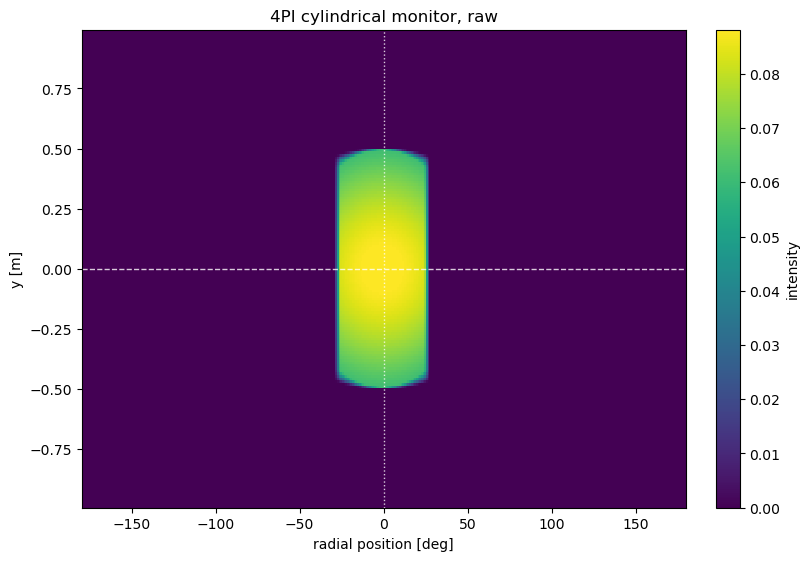

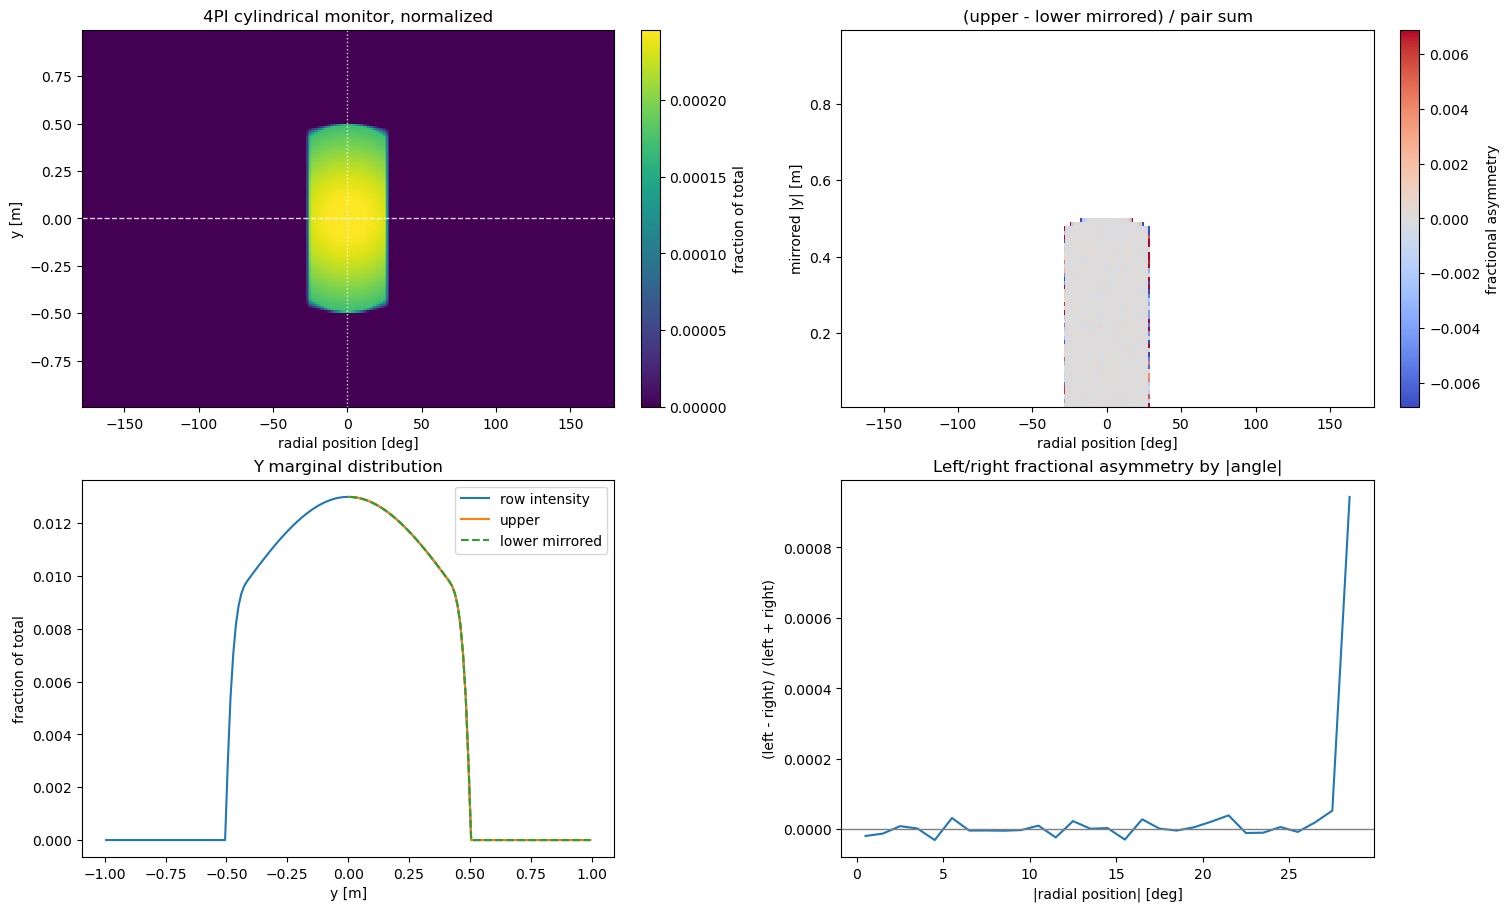

Record: /Users/christian/Documents/Study/bachelor_project/mcmini_verification/cylmon/cylmon/HS_4pisrc_to_cylmon_1e10/HS_srcsimple_to_cylmon_PSD.dat
  shape: (90, 180)
  xylimits: (-180.0, 180.0, -1.5, 1.5)
  total intensity: 8.27434e+13
  has I_err/sigma: True
  total events recorded: 8.27434e+09
  angular edge-column check before any crop:
          first column: sum=4.62216e+11, nonzero=90/90
    second_last column: sum=4.62297e+11, nonzero=90/90
           last column: sum=0, nonzero=0/90
  cylindrical angular-bin shift diagnostic:
    shift bins    matched pairs    valid pairs    left sum     right sum    |left-right|/(left+right)    crop
            -2               89             88    0.494383     0.494382                 1.90802e-06    dropped final angular bin
            -1               89             88    0.494384     0.494381                 2.53992e-06    dropped final angular bin
            +0               89             89    0.497208     0.497206                 1.6

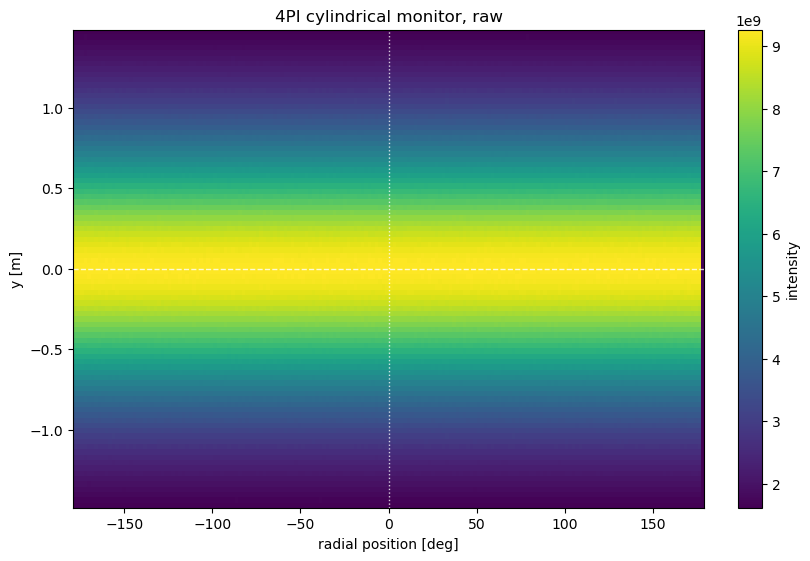

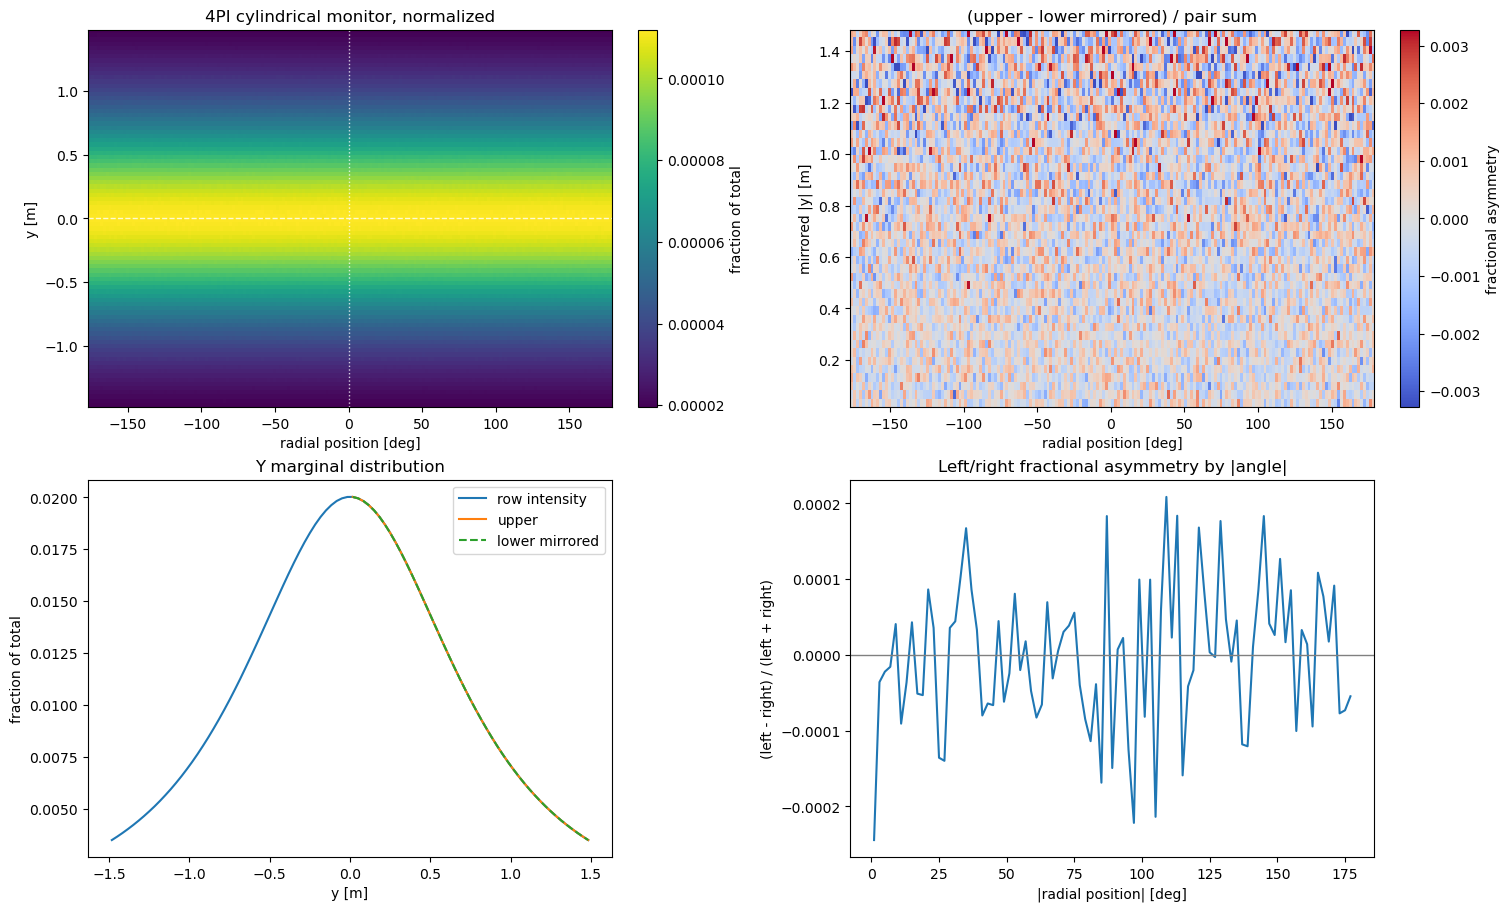

In [12]:
def load_monitor_arrays(dat_path):
    record = _parse_monitor_header(dat_path)
    y_bins, x_bins = record['shape']
    data = np.loadtxt(dat_path, comments='#')

    if data.ndim == 1:
        data = data.reshape(1, -1)

    if data.shape[0] < y_bins:
        raise ValueError(f'{dat_path} has only {data.shape[0]} data rows, expected at least {y_bins}')

    record['I'] = data[:y_bins, :]
    if data.shape[0] >= 2 * y_bins:
        record['I_err'] = data[y_bins:2 * y_bins, :]
        record['sigma'] = record['I_err']
    if data.shape[0] >= 3 * y_bins:
        record['N'] = data[2 * y_bins:3 * y_bins, :]

    return record


def latest_cylmon_directbeam_path():
    candidates = sorted(
        (workspace_root / 'mcmini_verification' / 'cylmon').glob('**/cylmon_directbeam.dat'),
        key=lambda path: path.stat().st_mtime,
    )
    if not candidates:
        return None
    return candidates[-1]


def _safe_fraction(numerator, denominator):
    return np.divide(
        numerator,
        denominator,
        out=np.full_like(np.asarray(numerator, dtype=float), np.nan),
        where=np.asarray(denominator) != 0.0,
    )


def print_pull_summary(label, diff, sigma):
    valid = np.isfinite(diff) & np.isfinite(sigma) & (sigma > 0.0)
    if not np.any(valid):
        print(f'  {label}: no finite uncertainty values available')
        return

    pull = diff[valid] / sigma[valid]
    chi2_dof = np.mean(pull**2)
    print(f'  {label}:')
    print(f'    valid bins:       {valid.sum()}')
    print(f'    mean pull:        {np.mean(pull):.6g}')
    print(f'    pull std:         {np.std(pull):.6g}')
    print(f'    chi2/dof:         {chi2_dof:.6g}')
    print(f'    max |pull|:       {np.max(np.abs(pull)):.6g}')


def _prepare_cylmon_angular_data(H_full, sigma_full, x_centers_full, shift, drop_last_angular_bin):
    H_shifted = np.roll(H_full, shift, axis=1) if shift != 0 else H_full
    sigma_shifted = None
    if sigma_full is not None:
        sigma_shifted = np.roll(sigma_full, shift, axis=1) if shift != 0 else sigma_full

    if drop_last_angular_bin:
        if shift > 0:
            return H_shifted[:, 1:], x_centers_full[1:], sigma_shifted[:, 1:] if sigma_shifted is not None else None, 'dropped first angular bin after right shift'
        return H_shifted[:, :-1], x_centers_full[:-1], sigma_shifted[:, :-1] if sigma_shifted is not None else None, 'dropped final angular bin'

    return H_shifted, x_centers_full, sigma_shifted, 'using all angular bins'


def _left_right_angular_fraction(H, x_centers):
    total = np.nansum(H)
    H_norm = H / total if total > 0.0 else H * np.nan
    column_sums = np.nansum(H_norm, axis=0)
    pairs = []
    for left_idx, phi in enumerate(x_centers):
        if phi < 0.0:
            right_matches = np.where(np.isclose(x_centers, -phi))[0]
            if len(right_matches):
                pairs.append((left_idx, int(right_matches[0])))
    if not pairs:
        return 0, 0, np.nan, np.nan, np.nan
    pairs = np.asarray(pairs, dtype=int)
    valid_pairs = pairs[(column_sums[pairs[:, 0]] > 0.0) & (column_sums[pairs[:, 1]] > 0.0)]
    if len(valid_pairs) == 0:
        return len(pairs), 0, np.nan, np.nan, np.nan
    left_sum = np.nansum(H_norm[:, valid_pairs[:, 0]])
    right_sum = np.nansum(H_norm[:, valid_pairs[:, 1]])
    frac = (left_sum - right_sum) / (left_sum + right_sum)
    return len(pairs), len(valid_pairs), left_sum, right_sum, frac


def plot_4pi_cylmon_symmetry(
    dat_path=None,
    drop_last_angular_bin=True,
    angular_bin_shift=cylinder_monitor_angular_bin_shift,
):
    if dat_path is None:
        dat_path = latest_cylmon_directbeam_path()
        if dat_path is None:
            raise FileNotFoundError(
                'No cylmon_directbeam.dat found under mcmini_verification/cylmon. '
                'Run the 4PI cylmon simulation first, or pass dat_path explicitly.'
            )
    dat_path = Path(dat_path)

    record = load_monitor_arrays(dat_path)
    H_full = record['I']
    sigma_full = record.get('sigma')
    x_centers_full, y_centers = coordinate_centers(record)

    print(f'Record: {dat_path}')
    print(f'  shape: {H_full.shape}')
    print(f'  xylimits: {record.get("xylimits")}')
    print(f'  total intensity: {np.nansum(H_full):.6g}')
    print(f'  has I_err/sigma: {sigma_full is not None}')
    if 'N' in record:
        print(f'  total events recorded: {np.nansum(record["N"]):.6g}')

    print('  angular edge-column check before any crop:')
    for idx, name in [(0, 'first'), (-2, 'second_last'), (-1, 'last')]:
        column = H_full[:, idx]
        print(
            f'    {name:>11} column: '
            f'sum={np.nansum(column):.6g}, '
            f'nonzero={np.count_nonzero(np.nan_to_num(column))}/{len(column)}'
        )

    print('  cylindrical angular-bin shift diagnostic:')
    print('    shift bins    matched pairs    valid pairs    left sum     right sum    |left-right|/(left+right)    crop')
    for shift in cylinder_shift_diagnostic_shifts:
        H_candidate, x_candidate, _, crop_note = _prepare_cylmon_angular_data(
            H_full,
            sigma_full,
            x_centers_full,
            shift,
            drop_last_angular_bin,
        )
        matched, valid, left_sum_shift, right_sum_shift, frac_shift = _left_right_angular_fraction(H_candidate, x_candidate)
        print(
            f'    {shift:+10d}'
            f'    {matched:13d}'
            f'    {valid:11d}'
            f'    {left_sum_shift:8.6g}'
            f'    {right_sum_shift:9.6g}'
            f'    {abs(frac_shift):24.6g}'
            f'    {crop_note}'
        )
    baseline_H, baseline_x, _, _ = _prepare_cylmon_angular_data(H_full, sigma_full, x_centers_full, 0, drop_last_angular_bin)
    _, _, _, _, baseline_frac = _left_right_angular_fraction(baseline_H, baseline_x)
    configured_H, configured_x, _, _ = _prepare_cylmon_angular_data(H_full, sigma_full, x_centers_full, angular_bin_shift, drop_last_angular_bin)
    _, _, _, _, configured_frac = _left_right_angular_fraction(configured_H, configured_x)
    baseline_asym = abs(baseline_frac)
    configured_asym = abs(configured_frac)
    reduction = 1.0 - configured_asym / baseline_asym if baseline_asym > 0.0 else np.nan
    significant = reduction >= cylinder_shift_significant_reduction_fraction
    print(f'    configured shift {angular_bin_shift:+d}: |asym| reduction = {reduction:.1%}')
    print(f'    significant reduction: {significant}')

    H, x_centers, sigma, crop_note = _prepare_cylmon_angular_data(
        H_full,
        sigma_full,
        x_centers_full,
        angular_bin_shift,
        drop_last_angular_bin,
    )
    print(f'  applied angular bin shift: {angular_bin_shift:+d}')
    print(f'  comparison crop: {crop_note}')

    total = np.nansum(H)
    H_norm = H / total if total > 0.0 else H * np.nan
    sigma_norm = sigma / total if sigma is not None and total > 0.0 else None

    row_profile = np.nansum(H_norm, axis=1)
    print('  top/bottom mirrored row check:')
    row_pairs = [(0, -1), (1, -2), (2, -3)]
    for bottom_idx, top_idx in row_pairs:
        bottom = row_profile[bottom_idx]
        top = row_profile[top_idx]
        frac = (top - bottom) / (top + bottom) if (top + bottom) > 0.0 else np.nan
        print(
            f'    y={y_centers[top_idx]: .6g} vs {y_centers[bottom_idx]: .6g} m: '
            f'top={top:.6g}, bottom={bottom:.6g}, (top-bottom)/(sum)={frac:.6g}'
        )

    half = min(np.sum(y_centers > 0.0), np.sum(y_centers < 0.0))
    lower_idx = np.where(y_centers < 0.0)[0][-half:]
    upper_idx = np.where(y_centers > 0.0)[0][:half]
    H_lower_mirror = H_norm[lower_idx, :][::-1, :]
    H_upper = H_norm[upper_idx, :]
    y_upper = y_centers[upper_idx]
    y_lower_mirror = -y_centers[lower_idx][::-1]

    y_diff = H_upper - H_lower_mirror
    y_sum = H_upper + H_lower_mirror
    y_pair_frac = _safe_fraction(y_diff, y_sum)
    upper_total = np.nansum(H_upper)
    lower_total = np.nansum(H_lower_mirror)
    y_global_frac = (upper_total - lower_total) / (upper_total + lower_total)
    print('  upper/lower mirror symmetry:')
    print(f'    upper sum:                   {upper_total:.6g}')
    print(f'    lower mirrored sum:          {lower_total:.6g}')
    print(f'    (upper-lower)/(upper+lower): {y_global_frac:.6g}')
    print(f'    mean |bin frac asym|:        {np.nanmean(np.abs(y_pair_frac)):.6g}')
    print(f'    RMS bin frac asym:           {np.sqrt(np.nanmean(y_pair_frac**2)):.6g}')

    if sigma_norm is not None:
        sigma_lower = sigma_norm[lower_idx, :][::-1, :]
        sigma_upper = sigma_norm[upper_idx, :]
        print_pull_summary(
            'upper/lower pull summary',
            H_upper - H_lower_mirror,
            np.sqrt(sigma_upper**2 + sigma_lower**2),
        )

    column_sums = np.nansum(H_norm, axis=0)
    pairs = []
    for left_idx, phi in enumerate(x_centers):
        if phi < 0.0:
            right_matches = np.where(np.isclose(x_centers, -phi))[0]
            if len(right_matches):
                pairs.append((left_idx, int(right_matches[0])))

    print('  left/right angular mirror symmetry:')
    pair_phi = np.array([])
    pair_frac_by_angle = np.array([])
    if pairs:
        pairs = np.asarray(pairs, dtype=int)
        valid_pairs = pairs[(column_sums[pairs[:, 0]] > 0.0) & (column_sums[pairs[:, 1]] > 0.0)]
        print(f'    matched pairs:               {len(pairs)}')
        print(f'    valid nonzero pairs:         {len(valid_pairs)}')
        left_sum = np.nansum(H_norm[:, valid_pairs[:, 0]])
        right_sum = np.nansum(H_norm[:, valid_pairs[:, 1]])
        lr_global_frac = (left_sum - right_sum) / (left_sum + right_sum)
        print(f'    left sum:                    {left_sum:.6g}')
        print(f'    right sum:                   {right_sum:.6g}')
        print(f'    (left-right)/(left+right):   {lr_global_frac:.6g}')

        pair_left = H_norm[:, valid_pairs[:, 0]]
        pair_right = H_norm[:, valid_pairs[:, 1]]
        pair_frac = _safe_fraction(pair_left - pair_right, pair_left + pair_right)
        print(f'    mean |bin frac asym|:        {np.nanmean(np.abs(pair_frac)):.6g}')
        print(f'    RMS bin frac asym:           {np.sqrt(np.nanmean(pair_frac**2)):.6g}')

        if sigma_norm is not None:
            print_pull_summary(
                'left/right pull summary',
                pair_left - pair_right,
                np.sqrt(sigma_norm[:, valid_pairs[:, 0]]**2 + sigma_norm[:, valid_pairs[:, 1]]**2),
            )

        left_columns = np.nansum(H_norm[:, valid_pairs[:, 0]], axis=0)
        right_columns = np.nansum(H_norm[:, valid_pairs[:, 1]], axis=0)
        pair_phi = np.abs(x_centers[valid_pairs[:, 0]])
        pair_frac_by_angle = _safe_fraction(left_columns - right_columns, left_columns + right_columns)
        order = np.argsort(np.abs(pair_frac_by_angle))[::-1][:8]
        print('    largest angular-pair fractional asymmetries:')
        for order_idx in order:
            left_idx, right_idx = valid_pairs[order_idx]
            print(
                f'      {x_centers[left_idx]: .1f} vs {x_centers[right_idx]: .1f} deg: '
                f'{pair_frac_by_angle[order_idx]: .6g}'
            )
    else:
        print('    no matched angular pairs found')

    vmin = np.nanpercentile(H_norm, 1.0)
    vmax = np.nanpercentile(H_norm, 99.5)

    # Standalone raw monitor before the angular shift or edge-bin crop.
    raw_vmin = np.nanpercentile(H_full, 1.0)
    raw_vmax = np.nanpercentile(H_full, 99.5)
    fig_monitor, ax_monitor = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
    im_monitor = ax_monitor.imshow(
        H_full,
        origin='lower',
        aspect='auto',
        extent=[x_centers_full[0], x_centers_full[-1], y_centers[0], y_centers[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=raw_vmin,
        vmax=raw_vmax,
    )
    ax_monitor.axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
    ax_monitor.axvline(0.0, color='white', linestyle=':', linewidth=1.0, alpha=0.8)
    ax_monitor.set_title('4PI cylindrical monitor, raw')
    ax_monitor.set_xlabel('radial position [deg]')
    ax_monitor.set_ylabel('y [m]')
    fig_monitor.colorbar(im_monitor, ax=ax_monitor, label='intensity')
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

    im0 = axes[0, 0].imshow(
        H_norm,
        origin='lower',
        aspect='auto',
        extent=[x_centers[0], x_centers[-1], y_centers[0], y_centers[-1]],
        interpolation='nearest',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[0, 0].axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
    axes[0, 0].axvline(0.0, color='white', linestyle=':', linewidth=1.0, alpha=0.8)
    axes[0, 0].set_title('4PI cylindrical monitor, normalized')
    axes[0, 0].set_xlabel('radial position [deg]')
    axes[0, 0].set_ylabel('y [m]')
    fig.colorbar(im0, ax=axes[0, 0], label='fraction of total')

    y_diff_frac = _safe_fraction(y_diff, y_sum)
    max_abs_y = np.nanpercentile(np.abs(y_diff_frac), 99.0)
    im1 = axes[0, 1].imshow(
        y_diff_frac,
        origin='lower',
        aspect='auto',
        extent=[x_centers[0], x_centers[-1], y_upper[0], y_upper[-1]],
        interpolation='nearest',
        cmap='coolwarm',
        vmin=-max_abs_y,
        vmax=max_abs_y,
    )
    axes[0, 1].set_title('(upper - lower mirrored) / pair sum')
    axes[0, 1].set_xlabel('radial position [deg]')
    axes[0, 1].set_ylabel('mirrored |y| [m]')
    fig.colorbar(im1, ax=axes[0, 1], label='fractional asymmetry')

    axes[1, 0].plot(y_centers, row_profile, label='row intensity')
    axes[1, 0].plot(y_upper, np.nansum(H_upper, axis=1), label='upper')
    axes[1, 0].plot(y_lower_mirror, np.nansum(H_lower_mirror, axis=1), '--', label='lower mirrored')
    axes[1, 0].set_title('Y marginal distribution')
    axes[1, 0].set_xlabel('y [m]')
    axes[1, 0].set_ylabel('fraction of total')
    axes[1, 0].legend()

    if pair_phi.size:
        order = np.argsort(pair_phi)
        axes[1, 1].plot(pair_phi[order], pair_frac_by_angle[order])
    axes[1, 1].axhline(0.0, color='0.5', linewidth=1.0)
    axes[1, 1].set_title('Left/right fractional asymmetry by |angle|')
    axes[1, 1].set_xlabel('|radial position| [deg]')
    axes[1, 1].set_ylabel('(left - right) / (left + right)')

    plt.show()


try:
    plot_4pi_cylmon_symmetry(
        # Pass an explicit path here if you want a specific run.
        workspace_root / 'mcmini_verification' / 'cylmon' / 'cylmon' / 'asymmetry_test' / 'cylmon_directbeam.dat',
        drop_last_angular_bin=True,
    )
except FileNotFoundError as exc:
    print(exc)


try:
    plot_4pi_cylmon_symmetry(
        # Pass an explicit path here if you want a specific run.
        workspace_root / 'mcmini_verification' / 'cylmon' / 'cylmon' / 'HS_4pisrc_to_cylmon_1e10' / 'HS_srcsimple_to_cylmon_PSD.dat',
        drop_last_angular_bin=True,
    )
except FileNotFoundError as exc:
    print(exc)
